In [1]:
import os
import numpy as np
import scipy.stats as stats
import torch
import copy
from torch import nn
from torch import optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
from sklearn.metrics import f1_score,classification_report,roc_auc_score, roc_curve
from torch.utils.data import TensorDataset, DataLoader,Subset
import re

In [2]:
with_cuda = torch.cuda.is_available()
if with_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [4]:
df = pd.read_csv("dataset_final.csv")
df

,cv_text,job_text,label
0,"experiences: titles: Cloud Engineer,Cloud En...",position title: Business Development & Sales A...,0
1,experiences: titles: Machine Learning Engine...,position title: Construction Project Manager- ...,0
2,"experiences: titles: Software Engineer, com...",position title: Senior Software Engineer compa...,1
3,"experiences: titles: Software Engineer,Softw...",position title: C++ Embedded Engineer with Sec...,1
4,"experiences: titles: Database Engineer,Datab...",position title: Work From Home - BEGIN IMMEDIA...,0
...,...,...,...
2977,"experiences: titles: React Developer,React D...",position title: Ecommerce Consultant company n...,0
2978,"experiences: titles: Vue Developer,Vue Devel...",position title: Digital Marketing Sales - Own ...,1
2979,"experiences: titles: Node.Js Developer,Node....",position title: Data Entry Clerk company name:...,1
2980,"experiences: titles: Flutter Developer, com...",position title: E-Commerce Manager company nam...,1


# Etape 1 : Construire le vocabulaire

In [5]:
class Dictionary:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = []
        self.nb_occ = {}

    def add_word(self, word):
        if word not in self.word2idx:
            self.idx2word.append(word)
            self.word2idx[word] = len(self.idx2word) - 1
            self.nb_occ[word] = 1
        else :
            self.nb_occ[word]+=1
        return self.word2idx[word]

    def __len__(self):
        return len(self.idx2word)


# Etape 2 : Tokenisation

In [6]:
def get_max_len(df):
      max_words = 0

      # CV
      for text in df["cv_text"]:
          nb_words = len(str(text).split())

          if nb_words > max_words:
              max_words = nb_words
      print("Taille maximale des mots sur cv", max_words)

      # Jobs
      for text in df["job_text"]:
          nb_words = len(str(text).split())

          if nb_words > max_words:
              max_words = nb_words

      print("Taille maximale des mots sur Jobs", max_words)

In [7]:
get_max_len(df)

Taille maximale des mots sur cv 111
Taille maximale des mots sur Jobs 992


In [90]:
class CorpusMatching:
    def __init__(self, df):
        self.dictionary = Dictionary()

        # Token spéciaux
        for token in ["<empty>", "<start>", "<end>"]:
            self.dictionary.add_word(token)

        #Construciton vocabulaire
        for text in df["cv_text"].tolist() + df["job_text"].tolist():
            words = self.clean_text(text).split()
            for word in words:
                self.dictionary.add_word(word)

        # Tokenisation
        self.cv_data,  self.cv_len  = self.tokenize(df["cv_text"])
        self.job_data, self.job_len = self.tokenize(df["job_text"])
        self.labels = torch.FloatTensor(df["label"].tolist())

    def clean_text(self, text):
        text = str(text).lower()
        text = re.sub(r"[^\w\s]", " ", text)   # enlève : , . / - etc.
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def tokenize(self, series, max_len=200):
      #Tockenisation par mot
        sentences = []
        lengths   = []

        for text in series:
            # <start> + mots + <end>
            words = self.clean_text(text).split()[:max_len-2]  # -2 pour start/end
            sent  = ["<start>"] + words + ["<end>"]
            lengths.append(len(sent))

            # Padding avec <empty>
            padded  = sent + ["<empty>"] * (max_len - len(sent))
            encoded = [self.dictionary.word2idx[w] for w in padded if w in self.dictionary.word2idx]
            sentences.append(encoded) #indices des mots de chaque CV

        data = torch.LongTensor(sentences) # (N, max_len)
        leng = torch.LongTensor(lengths)  # (N,) #utilisé par pack_padded_sequence pour ignorer le padding
        return data, leng

# Etape 3 : Créer le Dataset

In [126]:
corpus = CorpusMatching(df)

dataset = TensorDataset(corpus.cv_data, corpus.cv_len, corpus.job_data,corpus.job_len, corpus.labels)

train_set,val_set, test_set = torch.utils.data.random_split(dataset, [0.70,0.1, 0.2])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)
test_loader  = DataLoader(test_set, batch_size=32)


In [92]:
# Construire le vocabulaire
dct = Dictionary()
for text in df["cv_text"].tolist() + df["job_text"].tolist():
    for word in text.split():
        dct.add_word(word)

print(f"Taille du vocabulaire : {len(dct)}")

Taille du vocabulaire : 14618


#Construction des modèles


## Siamese LSTM

In [9]:
class SiameseLSTM(nn.Module):
    def __init__(self, ntokens, ninp, nhid, nlayers):
        super(SiameseLSTM, self).__init__()
        self.encoder = nn.Embedding(ntokens, ninp)
        self.rnn     = nn.LSTM(ninp, nhid, nlayers,
                               batch_first=True,
                               bidirectional=True) # Bi-LSTM

    def encode(self, x, lengths):
        emb = self.encoder(x) # (batch, seq, ninp)
        packed = pack_padded_sequence( #pour ne pas traiter le padding
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        out, (h, c) = self.rnn(packed) # h: (2*nlayers, batch, nhid)
        # Concatène le dernier état avant + arrière
        h_fwd = h[-2] # (batch, nhid)
        h_bwd = h[-1] # (batch, nhid)
        return torch.cat([h_fwd, h_bwd], dim=1) # (batch, nhid*2)

    def forward(self, cv, cv_len, job, job_len):
        h_cv  = self.encode(cv, cv_len)  # (batch, nhid*2)
        h_job = self.encode(job, job_len) # (batch, nhid*2)
        dist  = torch.norm(h_cv - h_job, dim=1) # distance entre les deux sorties
        return dist

## CNN


In [10]:
class CNN(nn.Module):
    def __init__(self, ntokens, n_filters=64, n_layers=3, semantic_dim=256):
        super().__init__()

        self.semantic_dim = semantic_dim # taille du vecteur de sortie de chaque bras du réseau siamois, ici je pense on va commencer à 256
        self.embedding = nn.Embedding(ntokens, 200)
        layers = []
        in_channels = 200

        for _ in range(n_layers):
            layers += [
                nn.Conv1d(in_channels, n_filters, kernel_size=10),
                nn.LeakyReLU(negative_slope=0.01),
                nn.MaxPool1d(kernel_size=3),
            ]
            in_channels = n_filters

        self.conv_blocks = nn.Sequential(*layers)

        # Calculer la taille aplatie dynamiquement
        with torch.no_grad():
            dummy    = torch.zeros(1,200,200)
            flat_dim = self.conv_blocks(dummy).view(1, -1).shape[1] # parce que je savais pas le faire

        self.fc = nn.Linear(flat_dim, semantic_dim)

    def encode(self, x):
        x = self.embedding(x)
        h = x = x.permute(0, 2, 1)
        h = self.conv_blocks(h)
        h = h.view(h.size(0), -1)
        return self.fc(h)


    def forward(self, cv, cv_lens, job, job_lens):
        h_cv  = self.encode(cv)
        h_job = self.encode(job)
        dist  = torch.norm(h_cv - h_job, dim=1)          # distance entre les deux sorties
        return dist


## Attention Layer

In [11]:
class AttentionLayer(nn.Module):
    def __init__(self, nembed):
        super(AttentionLayer, self).__init__()
        self.dk  = 256
        self.W_Q = nn.Linear(nembed, self.dk)
        self.W_K = nn.Linear(nembed, self.dk)
        self.W_V = nn.Linear(nembed, self.dk)

    def forward(self, x):
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        value = torch.matmul(Q, K.transpose(-2, -1))
        scores = value / np.sqrt(self.dk)
        soft   = F.softmax(scores,dim=-1)

        out = torch.matmul(soft,V)
        return out.mean(dim=1)

## CNN-AttentionLayer

In [12]:
class CNN_attention(nn.Module):

    def __init__(self, ntokens, n_filters=64, n_layers=3, semantic_dim=256):
        super().__init__()

        self.semantic_dim = semantic_dim # taille du vecteur de sortie de chaque bras du réseau siamois, ici je pense on va commencer à 256
        self.embedding = nn.Embedding(ntokens, 200)
        self.attention= AttentionLayer(n_filters)
        layers = []
        in_channels = 200

        for _ in range(n_layers):
            layers += [
                nn.Conv1d(in_channels, n_filters, kernel_size=10),
                nn.LeakyReLU(negative_slope=0.01),
                nn.MaxPool1d(kernel_size=3),
            ]
            in_channels = n_filters

        self.conv_blocks = nn.Sequential(*layers)
        self.fc = nn.Linear(self.attention.dk, semantic_dim)

    def encode(self, x):
        x = self.embedding(x)
        h = x = x.permute(0, 2, 1)
        h = self.conv_blocks(h)
        h = h.permute(0, 2, 1)
        h = self.attention(h)
        return self.fc(h)


    def forward(self, cv, cv_lens, job, job_lens):
        h_cv  = self.encode(cv)
        h_job = self.encode(job)
        dist  = torch.norm(h_cv - h_job, dim=1)
        return dist


## LSTM-Attention Layer

In [13]:
class SiameseLSTMAtt(nn.Module):
    def __init__(self, ntokens, ninp, nhid, nlayers):
        super(SiameseLSTMAtt, self).__init__()
        self.encoder = nn.Embedding(ntokens, ninp)
        self.rnn     = nn.LSTM(ninp, nhid, nlayers,
                               batch_first=True,
                               bidirectional=True)
        self.attention = AttentionLayer(nhid * 2) # Initialize attention layer, *2 for bidirectional

    def encode(self, x, lengths):
        emb = self.encoder(x)
        packed = pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        out, (h, c) = self.rnn(packed)

        out_padded, _ = pad_packed_sequence(out, batch_first=True)

        attended_output = self.attention(out_padded)

        return attended_output

    def forward(self, cv, cv_len, job, job_len):
        h_cv  = self.encode(cv, cv_len)
        h_job = self.encode(job, job_len)
        dist  = torch.norm(h_cv - h_job, dim=1)
        return dist

# Construction de la perte


In [14]:
def contrastive_loss(dist, labels, margin=1.0):
    loss = labels * dist**2 + (1 - labels) * torch.clamp(margin - dist, min=0)**2
    return loss.mean()

# Construction de l'entrainement

In [15]:
def train_model(train_loader, val_loader, model, optimizer, nepochs, model_name):
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_model_path = f"best_{model_name}.pt"

    for epoch in range(nepochs):
        model.train()
        train_loss = 0.

        for cv, cv_lens, job, job_lens, labels in train_loader:
            cv = cv.to(device)
            job = job.to(device)
            cv_lens = cv_lens.to(device)
            job_lens = job_lens.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            dist = model(cv, cv_lens, job, job_lens)
            loss = contrastive_loss(dist, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0.

        with torch.no_grad():
            for cv, cv_lens, job, job_lens, labels in val_loader:
                cv = cv.to(device)
                job = job.to(device)
                cv_lens = cv_lens.to(device)
                job_lens = job_lens.to(device)
                labels = labels.to(device)

                dist = model(cv, cv_lens, job, job_lens)
                loss = contrastive_loss(dist, labels)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_model_path)

            print(
                f"Best model saved: {best_model_path} | "
                f"Epoch {epoch+1} | Val Loss: {avg_val_loss:.4f}"
            )

        if epoch % 10 == 0:
            print(
                f"{model_name} | Epoch {epoch+1}/{nepochs} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f}"
            )
    # Courbe overfitting
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Courbe d'overfitting")
    plt.legend()
    plt.grid(True)
    plt.show()

    return train_losses, val_losses

# Entrainement


In [34]:
ntokens = len(corpus.dictionary)   # taille du vocabulaire
ninp    = 100                      # dimension embedding
nhid    = 128                       # dimension hidden LSTM
nlayers = 2                          # nombre de couches LSTM
nepochs = 30

Best model saved: best_cnn.pt | Epoch 1 | Val Loss: 0.1749
cnn | Epoch 1/30 | Train Loss: 0.2306 | Val Loss: 0.1749
Best model saved: best_cnn.pt | Epoch 2 | Val Loss: 0.1489
Best model saved: best_cnn.pt | Epoch 4 | Val Loss: 0.1300
Best model saved: best_cnn.pt | Epoch 5 | Val Loss: 0.1115
Best model saved: best_cnn.pt | Epoch 6 | Val Loss: 0.1103
Best model saved: best_cnn.pt | Epoch 8 | Val Loss: 0.1080
Best model saved: best_cnn.pt | Epoch 9 | Val Loss: 0.1062
cnn | Epoch 11/30 | Train Loss: 0.0430 | Val Loss: 0.1132
Best model saved: best_cnn.pt | Epoch 12 | Val Loss: 0.1036
Best model saved: best_cnn.pt | Epoch 14 | Val Loss: 0.0988
cnn | Epoch 21/30 | Train Loss: 0.0349 | Val Loss: 0.1059


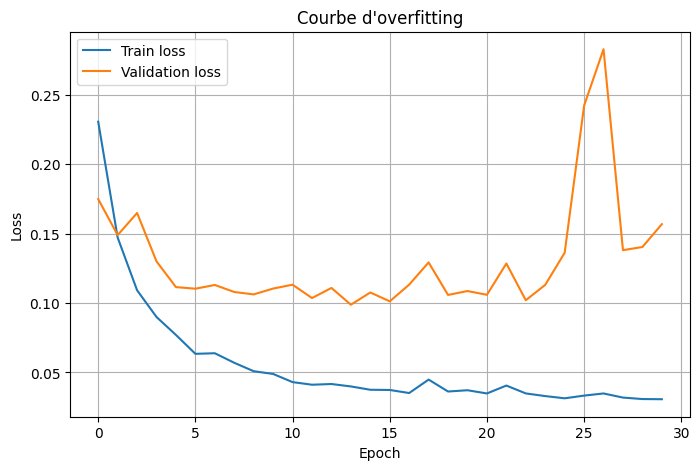

In [ ]:
#Entrainement CNN
model_cnn=CNN(ntokens).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)

# 3. Lancer l'entraînement
train_losses = train_model(train_loader, val_loader, model_cnn, optimizer, 30, "cnn")


Best model saved: best_cnn_att.pt | Epoch 1 | Val Loss: 0.1747
cnn_att | Epoch 1/30 | Train Loss: 0.2023 | Val Loss: 0.1747
Best model saved: best_cnn_att.pt | Epoch 2 | Val Loss: 0.1474
Best model saved: best_cnn_att.pt | Epoch 3 | Val Loss: 0.1388
Best model saved: best_cnn_att.pt | Epoch 4 | Val Loss: 0.1337
Best model saved: best_cnn_att.pt | Epoch 5 | Val Loss: 0.1236
Best model saved: best_cnn_att.pt | Epoch 6 | Val Loss: 0.1173
Best model saved: best_cnn_att.pt | Epoch 8 | Val Loss: 0.1140
Best model saved: best_cnn_att.pt | Epoch 9 | Val Loss: 0.1087
cnn_att | Epoch 11/30 | Train Loss: 0.0475 | Val Loss: 0.1137
Best model saved: best_cnn_att.pt | Epoch 14 | Val Loss: 0.1075
Best model saved: best_cnn_att.pt | Epoch 17 | Val Loss: 0.1070
cnn_att | Epoch 21/30 | Train Loss: 0.0335 | Val Loss: 0.1111


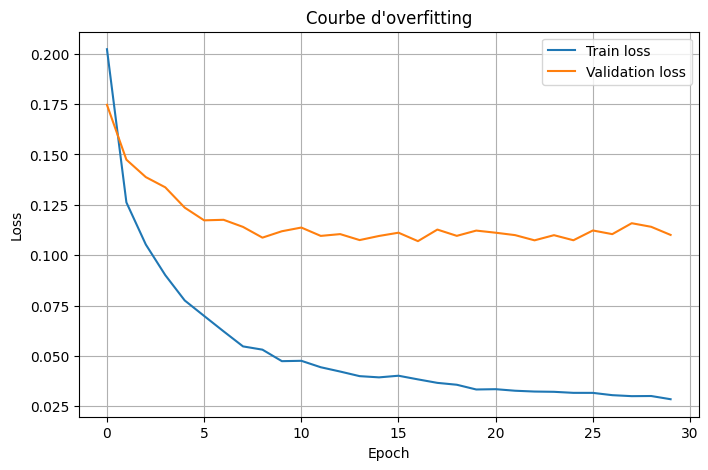

In [ ]:
#Entrainement CNN-AttentionLayer

model_cnn_att=CNN_attention(ntokens).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_cnn_att.parameters(), lr=1e-4)

# 3. Lancer l'entraînement

train_losses = train_model(train_loader,val_loader, model_cnn_att, optimizer, 30,"cnn_att")


Best model saved: best_lstm.pt | Epoch 1 | Val Loss: 0.1238
lstm | Epoch 1/30 | Train Loss: 0.1494 | Val Loss: 0.1238
Best model saved: best_lstm.pt | Epoch 2 | Val Loss: 0.1165
Best model saved: best_lstm.pt | Epoch 3 | Val Loss: 0.0987
Best model saved: best_lstm.pt | Epoch 5 | Val Loss: 0.0914
Best model saved: best_lstm.pt | Epoch 6 | Val Loss: 0.0851
Best model saved: best_lstm.pt | Epoch 9 | Val Loss: 0.0767
lstm | Epoch 11/30 | Train Loss: 0.0417 | Val Loss: 0.0969
lstm | Epoch 21/30 | Train Loss: 0.0295 | Val Loss: 0.1271


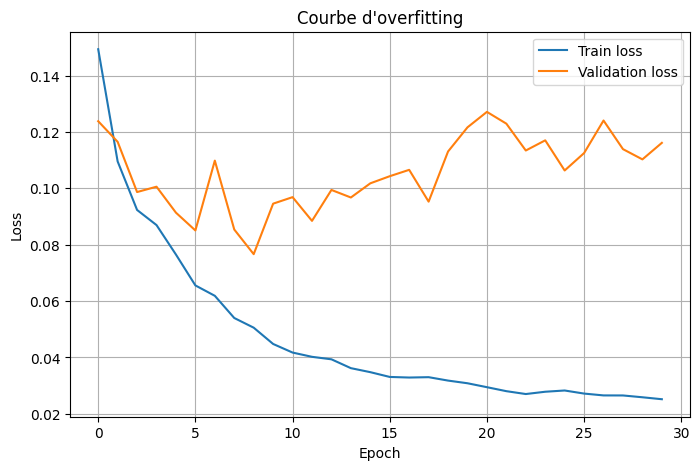

In [56]:
#Entrainement Bi-LSTM

model_lstm=SiameseLSTM(ntokens, ninp, nhid, nlayers).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

# 3. Lancer l'entraînement

train_losses = train_model(train_loader, val_loader,model_lstm, optimizer, 30,"lstm")


Best model saved: best_lstm_att.pt | Epoch 1 | Val Loss: 0.1638
lstm_att | Epoch 1/30 | Train Loss: 0.1799 | Val Loss: 0.1638
Best model saved: best_lstm_att.pt | Epoch 2 | Val Loss: 0.1139
Best model saved: best_lstm_att.pt | Epoch 3 | Val Loss: 0.1034
Best model saved: best_lstm_att.pt | Epoch 4 | Val Loss: 0.0848
Best model saved: best_lstm_att.pt | Epoch 7 | Val Loss: 0.0848
lstm_att | Epoch 11/30 | Train Loss: 0.0394 | Val Loss: 0.1093
Best model saved: best_lstm_att.pt | Epoch 12 | Val Loss: 0.0800
lstm_att | Epoch 21/30 | Train Loss: 0.0289 | Val Loss: 0.1059


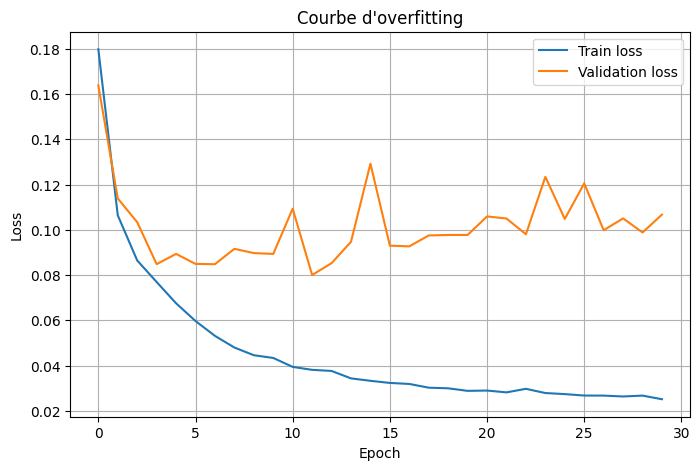

In [57]:
#Entrainement LSTM-AttentionLayer-P

model_lstm_att=SiameseLSTMAtt(ntokens, ninp, nhid, nlayers).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_lstm_att.parameters(), lr=1e-3)

# 3. Lancer l'entraînement
train_losses = train_model(train_loader,val_loader, model_lstm_att, optimizer, 30,"lstm_att")


# Evaluation

In [43]:
def evaluate(loader, model, device, threshold=0.6):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_scores = []

    with torch.no_grad():
        for cv, cv_len, job, job_len, labels in loader:

            cv = cv.to(device)
            job = job.to(device)
            labels = labels.to(device)

            dist = model(cv, cv_len, job, job_len)  # (batch,)

            # distance petite => match => 1
            preds = (dist < threshold).long()

            labels = labels.long()

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_scores.extend((-dist).cpu().tolist())

    accuracy = correct / total
    print(f"Accuracy : {accuracy:4f}")
    print(f"F1 macro : {f1_score(all_labels, all_preds, average='macro'):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(all_labels, all_scores):.4f}")
    print(classification_report(all_labels, all_preds))


    return accuracy

In [ ]:
#Choix du seuil
for threshold in [0.4, 0.5, 0.6, 0.7, 0.8, 1]:
    print("Threshold:", threshold)
    evaluate(test_loader, model_lstm, device, threshold)

Threshold: 0.4
Accuracy : 0.848993
F1 macro : 0.8479
ROC-AUC  : 0.9258
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       296
           1       0.93      0.76      0.84       300

    accuracy                           0.85       596
   macro avg       0.86      0.85      0.85       596
weighted avg       0.86      0.85      0.85       596

Threshold: 0.5
Accuracy : 0.850671
F1 macro : 0.8504
ROC-AUC  : 0.9258
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       296
           1       0.89      0.80      0.84       300

    accuracy                           0.85       596
   macro avg       0.85      0.85      0.85       596
weighted avg       0.85      0.85      0.85       596

Threshold: 0.6
Accuracy : 0.864094
F1 macro : 0.8640
ROC-AUC  : 0.9258
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       296
           1       0.89 

In [ ]:
models = [
    ("cnn", model_cnn),("cnn_att", model_cnn_att),("lstm", model_lstm), ("lstm_att", model_lstm_att)
]

for model_name, model in models:
  path = f"best_{model_name}.pt"

  model.load_state_dict(torch.load(path, map_location=device))
  model.eval()

  print(f"Evaluation du meilleur modèle : {model_name}")
  evaluate(test_loader, model, device)
  print()


Evaluation du meilleur modèle : cnn
Accuracy : 0.823826
F1 macro : 0.8223
ROC-AUC  : 0.9246
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       296
           1       0.78      0.91      0.84       300

    accuracy                           0.82       596
   macro avg       0.83      0.82      0.82       596
weighted avg       0.83      0.82      0.82       596


Evaluation du meilleur modèle : cnn_att
Accuracy : 0.854027
F1 macro : 0.8538
ROC-AUC  : 0.9352
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       296
           1       0.83      0.89      0.86       300

    accuracy                           0.85       596
   macro avg       0.86      0.85      0.85       596
weighted avg       0.86      0.85      0.85       596


Evaluation du meilleur modèle : lstm
Accuracy : 0.847315
F1 macro : 0.8471
ROC-AUC  : 0.9336
              precision    recall  f1-score   support

        

# TF-IDF + Logistic Regression

In [103]:
#Tokenisation pour TF-IDF
def clean_text(text):
        text = str(text).lower()
        text = re.sub(r"[^\w\s]", " ", text)   # enlève : , . / - etc.
        text = re.sub(r"\s+", " ", text).strip()
        return text

df["cv_tokens"] = df["cv_text"].apply(clean_text).astype(str).str.split()
df["job_tokens"] = df["job_text"].apply(clean_text).astype(str).str.split()
df

,cv_text,job_text,label,cv_tokens,job_tokens
0,"experiences: titles: Cloud Engineer,Cloud En...",position title: Business Development & Sales A...,0,"[experiences, titles, cloud, engineer, cloud, ...","[position, title, business, development, sales..."
1,experiences: titles: Machine Learning Engine...,position title: Construction Project Manager- ...,0,"[experiences, titles, machine, learning, engin...","[position, title, construction, project, manag..."
2,"experiences: titles: Software Engineer, com...",position title: Senior Software Engineer compa...,1,"[experiences, titles, software, engineer, comp...","[position, title, senior, software, engineer, ..."
3,"experiences: titles: Software Engineer,Softw...",position title: C++ Embedded Engineer with Sec...,1,"[experiences, titles, software, engineer, soft...","[position, title, c, embedded, engineer, with,..."
4,"experiences: titles: Database Engineer,Datab...",position title: Work From Home - BEGIN IMMEDIA...,0,"[experiences, titles, database, engineer, data...","[position, title, work, from, home, begin, imm..."
...,...,...,...,...,...
2977,"experiences: titles: React Developer,React D...",position title: Ecommerce Consultant company n...,0,"[experiences, titles, react, developer, react,...","[position, title, ecommerce, consultant, compa..."
2978,"experiences: titles: Vue Developer,Vue Devel...",position title: Digital Marketing Sales - Own ...,1,"[experiences, titles, vue, developer, vue, dev...","[position, title, digital, marketing, sales, o..."
2979,"experiences: titles: Node.Js Developer,Node....",position title: Data Entry Clerk company name:...,1,"[experiences, titles, node, js, developer, nod...","[position, title, data, entry, clerk, company,..."
2980,"experiences: titles: Flutter Developer, com...",position title: E-Commerce Manager company nam...,1,"[experiences, titles, flutter, developer, comp...","[position, title, e, commerce, manager, compan..."


In [104]:
class TFIDFEmbedder:
    def __init__(self, vocab):
        self.vocab = vocab
        self.idf   = None
        self.n_docs = 0

    def fit(self, all_tokens_list):
        """Calcule les IDF sur le corpus."""
        self.n_docs = len(all_tokens_list)
        df = np.zeros(len(self.vocab.word2idx), dtype=np.float32)

        for doc in all_tokens_list:
            seen = set()
            for t in doc:
                idx = self.vocab.word2idx.get(t, -1)
                if idx >= 0 and idx not in seen:
                    df[idx] += 1
                    seen.add(idx)

        self.idf = np.log((self.n_docs + 1) / (df + 1)) + 1.0
        return self

    def transform(self, tokens):
        vec = np.zeros(len(self.vocab.word2idx), dtype=np.float32)
        if not tokens:
            return vec

        count   = Counter(tokens)
        max_tf  = max(count.values())
        for t, freq in count.items():
            idx = self.vocab.word2idx.get(t, -1)
            if idx >= 0:
                vec[idx] = (freq / max_tf) * self.idf[idx]

        # Normalisation L2
        norm = np.linalg.norm(vec)
        if norm > 0:
            vec /= norm
        return vec

    def transform_corpus(self, all_tokens_list):
        """Vectorise un corpus entier → (n_docs, vocab.size)"""
        return np.stack([self.transform(doc) for doc in all_tokens_list],
                        axis=0).astype(np.float32)

In [127]:
from collections import Counter

corpus = CorpusMatching(df)

tfidf = TFIDFEmbedder(corpus.dictionary)

# Combine all tokenized documents for TF-IDF fitting
all_docs = df["cv_tokens"].tolist() + df["job_tokens"].tolist()
tfidf.fit(all_docs)

X_cv = tfidf.transform_corpus(df["cv_tokens"])
X_job = tfidf.transform_corpus(df["job_tokens"])

In [128]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

X_combined = np.abs(X_cv - X_job)
y = df['label'].values

# recupérer les indices de train/test pour la réproduction
train_indices = train_set.indices
test_indices = test_set.indices

# on split sur les mêmes indices
X_train_lr = X_combined[train_indices]
X_test_lr = X_combined[test_indices]
y_train_lr = y[train_indices]
y_test_lr = y[test_indices]

In [ ]:
lr_model = LogisticRegression(random_state=42, n_jobs=-1)
lr_model.fit(X_train_lr, y_train_lr)

y_pred_lr = lr_model.predict(X_test_lr)
y_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]


print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test_lr, y_pred_lr):.4f}")
print(f"F1 Score (macro): {f1_score(y_test_lr, y_pred_lr, average='macro'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_lr, y_proba_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_lr, y_pred_lr))

# Essai Sur le split


In [27]:
def cv_cold(df, test_ratio=0.2, val_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed) # Seed pour avoir le meme résultat à chaque fois
    unique_cvs = rng.permutation(df['cv_text'].unique()) # je ne garde que les CV unique sur le dataset et je les mélange aléatoirement

    n = len(unique_cvs)
    n_test = int(n * test_ratio) # nombre à garder dans le test
    n_val = int(n * val_ratio) # nombre à garder dans le val

    test_cvs  = set(unique_cvs[:n_test]) # je prends les n_tests premiers
    val_cvs   = set(unique_cvs[n_test:n_test + n_val])
    train_cvs = set(unique_cvs[n_test + n_val:])

    train_idx = df.index[df['cv_text'].isin(train_cvs)].to_numpy() # convertir en numpy pour le subset
    val_idx   = df.index[df['cv_text'].isin(val_cvs)].to_numpy()
    test_idx  = df.index[df['cv_text'].isin(test_cvs)].to_numpy()
    return train_idx, val_idx, test_idx

In [28]:
def job_cold(df, test_ratio=0.2, val_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed)
    unique_jobs = rng.permutation(df['job_text'].unique())

    n = len(unique_jobs)
    n_test = int(n * test_ratio)
    n_val  = int(n * val_ratio)

    test_jobs  = set(unique_jobs[:n_test])
    val_jobs   = set(unique_jobs[n_test:n_test + n_val])
    train_jobs = set(unique_jobs[n_test + n_val:])

    train_idx = df.index[df['job_text'].isin(train_jobs)].to_numpy()
    val_idx   = df.index[df['job_text'].isin(val_jobs)].to_numpy()
    test_idx  = df.index[df['job_text'].isin(test_jobs)].to_numpy()
    return train_idx, val_idx, test_idx

In [29]:
def doubly_cold(df, test_ratio=0.2, val_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed)

    # 1. Découper les CVs
    unique_cvs = rng.permutation(df['cv_text'].unique())
    n_cv = len(unique_cvs)
    n_cv_test = int(n_cv * test_ratio)
    n_cv_val  = int(n_cv * val_ratio)
    test_cvs  = set(unique_cvs[:n_cv_test])
    val_cvs   = set(unique_cvs[n_cv_test:n_cv_test + n_cv_val])
    train_cvs = set(unique_cvs[n_cv_test + n_cv_val:])

    # 2. Découper les jobs (avec une autre seed pour les rendre indépendants)
    rng_jobs = np.random.default_rng(seed + 1)
    unique_jobs = rng_jobs.permutation(df['job_text'].unique())
    n_job = len(unique_jobs)
    n_job_test = int(n_job * test_ratio)
    n_job_val  = int(n_job * val_ratio)
    test_jobs  = set(unique_jobs[:n_job_test])
    val_jobs   = set(unique_jobs[n_job_test:n_job_test + n_job_val])
    train_jobs = set(unique_jobs[n_job_test + n_job_val:])

    # 3. Ne garder QUE les paires "diagonales"
    in_train = df['cv_text'].isin(train_cvs) & df['job_text'].isin(train_jobs)
    in_val   = df['cv_text'].isin(val_cvs)   & df['job_text'].isin(val_jobs)
    in_test  = df['cv_text'].isin(test_cvs)  & df['job_text'].isin(test_jobs)

    return df.index[in_train].to_numpy(), df.index[in_val].to_numpy(), df.index[in_test].to_numpy()


In [30]:
def describe_split(df, train_idx, val_idx, test_idx, nom=""):
    tr = df.iloc[train_idx]
    va = df.iloc[val_idx]
    te = df.iloc[test_idx]

    print(f"{nom}")
    print(f"Train: {len(tr)} pairs ")
    print(f"Val  : {len(va)} pairs ")
    print(f"Test : {len(te)} pairs ")
    print(f"Nombre de pair utilisé: {len(tr)+len(va)+len(te)} / {len(df)} "
          f"(non utilisé: {len(df) - len(tr) - len(va) - len(te)})")

    # Vérif fuite
    cv_leak_test  = set(tr['cv_text'])  & set(te['cv_text'])
    job_leak_test = set(tr['job_text']) & set(te['job_text'])
    print(f"CV leak: {len(cv_leak_test)} CVs partagés")
    print(f"Job leak: {len(job_leak_test)} jobs partagés")


In [32]:
# Pour des splits déterministes, df doit avoir un index propre
df = df.reset_index(drop=True)

corpus = CorpusMatching(df)
dataset = TensorDataset(corpus.cv_data, corpus.cv_len,
                        corpus.job_data, corpus.job_len, corpus.labels)


train_idx, val_idx, test_idx = cv_cold(df, test_ratio=0.2, val_ratio=0.1, seed=42)
describe_split(df, train_idx, val_idx, test_idx, "cv")

train_set_cv = Subset(dataset, train_idx)
val_set_cv   = Subset(dataset, val_idx)
test_set_cv  = Subset(dataset, test_idx)

train_loader_cv = DataLoader(train_set_cv, batch_size=32, shuffle=True)
val_loader_cv = DataLoader(val_set_cv,   batch_size=32)
test_loader_cv = DataLoader(test_set_cv,  batch_size=32)

train_idx, val_idx, test_idx = job_cold(df, test_ratio=0.2, val_ratio=0.1, seed=42)
describe_split(df, train_idx, val_idx, test_idx, "job")

train_set_job = Subset(dataset, train_idx)
val_set_job = Subset(dataset, val_idx)
test_set_job = Subset(dataset, test_idx)

train_loader_job = DataLoader(train_set_job, batch_size=32, shuffle=True)
val_loader_job = DataLoader(val_set_job,   batch_size=32)
test_loader_job = DataLoader(test_set_job,  batch_size=32)

train_idx, val_idx, test_idx = doubly_cold(df, test_ratio=0.2, val_ratio=0.1, seed=42)
describe_split(df, train_idx, val_idx, test_idx, "double")

train_set_double = Subset(dataset, train_idx)
val_set_double = Subset(dataset, val_idx)
test_set_double = Subset(dataset, test_idx)

train_loader_double = DataLoader(train_set_double, batch_size=32, shuffle=True)
val_loader_double = DataLoader(val_set_double,   batch_size=32)
test_loader_double = DataLoader(test_set_double,  batch_size=32)


cv
Train: 2077 pairs 
Val  : 311 pairs 
Test : 594 pairs 
Nombre de pair utilisé: 2982 / 2982 (non utilisé: 0)
CV leak: 0 CVs partagés
Job leak: 191 jobs partagés
job
Train: 2212 pairs 
Val  : 214 pairs 
Test : 556 pairs 
Nombre de pair utilisé: 2982 / 2982 (non utilisé: 0)
CV leak: 317 CVs partagés
Job leak: 0 jobs partagés
double
Train: 1501 pairs 
Val  : 33 pairs 
Test : 104 pairs 
Nombre de pair utilisé: 1638 / 2982 (non utilisé: 1344)
CV leak: 0 CVs partagés
Job leak: 0 jobs partagés


## CV

Best model saved: best_lstm_cv.pt | Epoch 1 | Val Loss: 0.1531
lstm_cv | Epoch 1/30 | Train Loss: 0.1597 | Val Loss: 0.1531
Best model saved: best_lstm_cv.pt | Epoch 2 | Val Loss: 0.1369
Best model saved: best_lstm_cv.pt | Epoch 3 | Val Loss: 0.1260
lstm_cv | Epoch 11/30 | Train Loss: 0.0450 | Val Loss: 0.1592
lstm_cv | Epoch 21/30 | Train Loss: 0.0302 | Val Loss: 0.1628


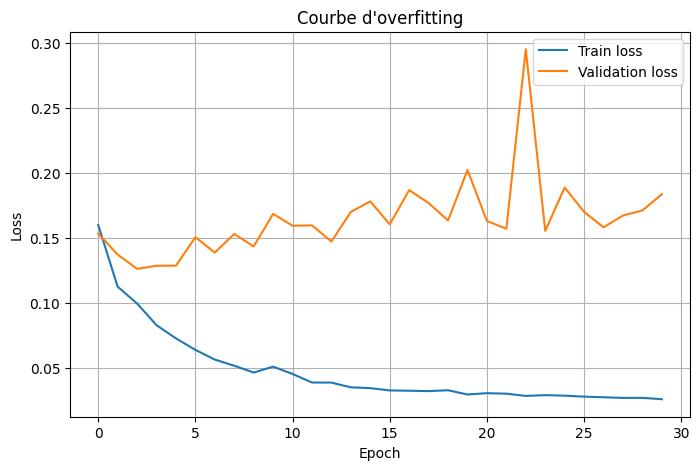

In [36]:
#Entrainement Bi-LSTM

model_lstm_cv=SiameseLSTM(ntokens, ninp, nhid, nlayers).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_lstm_cv.parameters(), lr=1e-3)

# 3. Lancer l'entraînement

train_losses = train_model(train_loader_cv, val_loader_cv,model_lstm_cv, optimizer, 30,"lstm_cv")


Best model saved: best_lstm_att_cv.pt | Epoch 1 | Val Loss: 0.2010
lstm_att_cv | Epoch 1/30 | Train Loss: 0.1653 | Val Loss: 0.2010
Best model saved: best_lstm_att_cv.pt | Epoch 2 | Val Loss: 0.1942
Best model saved: best_lstm_att_cv.pt | Epoch 3 | Val Loss: 0.1429
Best model saved: best_lstm_att_cv.pt | Epoch 4 | Val Loss: 0.1418
Best model saved: best_lstm_att_cv.pt | Epoch 7 | Val Loss: 0.1406
Best model saved: best_lstm_att_cv.pt | Epoch 8 | Val Loss: 0.1366
lstm_att_cv | Epoch 11/30 | Train Loss: 0.0403 | Val Loss: 0.1429
Best model saved: best_lstm_att_cv.pt | Epoch 12 | Val Loss: 0.1354
Best model saved: best_lstm_att_cv.pt | Epoch 15 | Val Loss: 0.1302
Best model saved: best_lstm_att_cv.pt | Epoch 17 | Val Loss: 0.1254
lstm_att_cv | Epoch 21/30 | Train Loss: 0.0297 | Val Loss: 0.1360


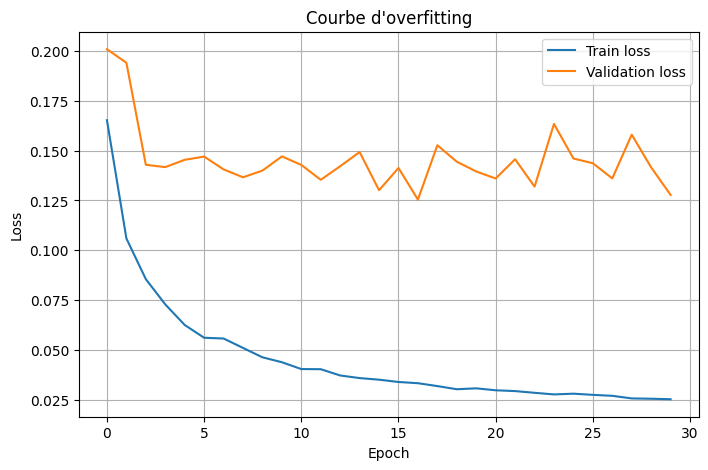

In [37]:
#Entrainement LSTM-AttentionLayer-P

model_lstm_att_cv=SiameseLSTMAtt(ntokens, ninp, nhid, nlayers).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_lstm_att_cv.parameters(), lr=1e-3)

# 3. Lancer l'entraînement
train_losses = train_model(train_loader_cv,val_loader_cv, model_lstm_att_cv, optimizer, 30,"lstm_att_cv")


## Job

Best model saved: best_lstm_job.pt | Epoch 1 | Val Loss: 0.1847
lstm_job | Epoch 1/30 | Train Loss: 0.1408 | Val Loss: 0.1847
Best model saved: best_lstm_job.pt | Epoch 5 | Val Loss: 0.1820
Best model saved: best_lstm_job.pt | Epoch 6 | Val Loss: 0.1784
Best model saved: best_lstm_job.pt | Epoch 7 | Val Loss: 0.1724
lstm_job | Epoch 11/30 | Train Loss: 0.0442 | Val Loss: 0.1911
lstm_job | Epoch 21/30 | Train Loss: 0.0273 | Val Loss: 0.1915


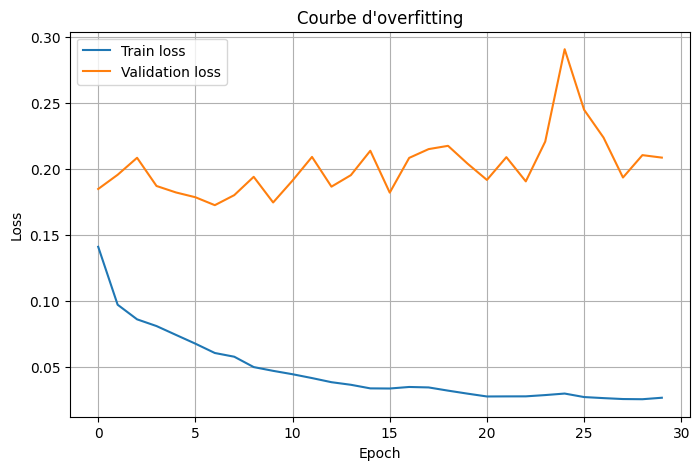

In [47]:
#Entrainement Bi-LSTM

model_lstm_job=SiameseLSTM(ntokens, ninp, nhid, nlayers).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_lstm_job.parameters(), lr=1e-3)

# 3. Lancer l'entraînement

train_losses = train_model(train_loader_job, val_loader_job,model_lstm_job, optimizer, 30,"lstm_job")


Best model saved: best_lstm_att_job.pt | Epoch 1 | Val Loss: 0.1970
lstm_att_job | Epoch 1/30 | Train Loss: 0.1663 | Val Loss: 0.1970
Best model saved: best_lstm_att_job.pt | Epoch 2 | Val Loss: 0.1812
Best model saved: best_lstm_att_job.pt | Epoch 3 | Val Loss: 0.1768
Best model saved: best_lstm_att_job.pt | Epoch 4 | Val Loss: 0.1716
Best model saved: best_lstm_att_job.pt | Epoch 6 | Val Loss: 0.1666
lstm_att_job | Epoch 11/30 | Train Loss: 0.0369 | Val Loss: 0.1726
Best model saved: best_lstm_att_job.pt | Epoch 14 | Val Loss: 0.1661
lstm_att_job | Epoch 21/30 | Train Loss: 0.0288 | Val Loss: 0.1741
Best model saved: best_lstm_att_job.pt | Epoch 22 | Val Loss: 0.1617


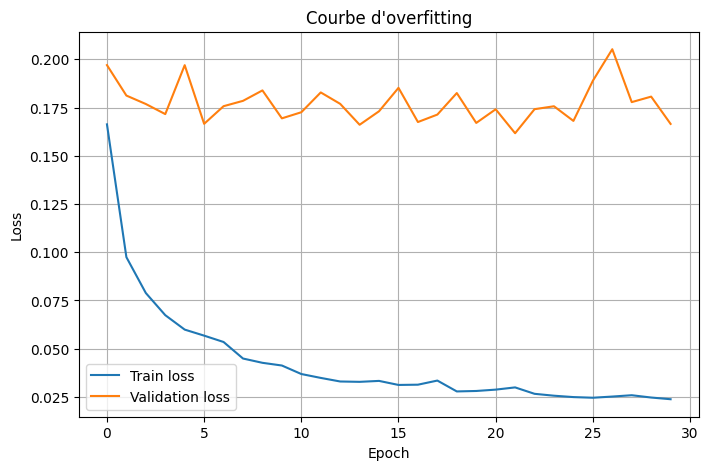

In [39]:
#Entrainement LSTM-AttentionLayer-P

model_lstm_att_job=SiameseLSTMAtt(ntokens, ninp, nhid, nlayers).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_lstm_att_job.parameters(), lr=1e-3)

# 3. Lancer l'entraînement
train_losses = train_model(train_loader_job,val_loader_job, model_lstm_att_job, optimizer, 30,"lstm_att_job")


## Double

Best model saved: best_lstm_job.pt | Epoch 1 | Val Loss: 0.1238
lstm_job | Epoch 1/30 | Train Loss: 0.1521 | Val Loss: 0.1238
Best model saved: best_lstm_job.pt | Epoch 3 | Val Loss: 0.1034
lstm_job | Epoch 11/30 | Train Loss: 0.0384 | Val Loss: 0.2427
lstm_job | Epoch 21/30 | Train Loss: 0.0268 | Val Loss: 0.3291


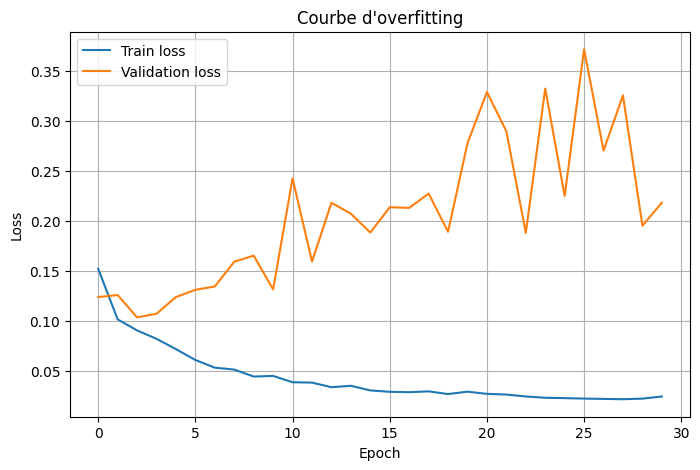

In [40]:
#Entrainement Bi-LSTM

model_lstm_db=SiameseLSTM(ntokens, ninp, nhid, nlayers).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_lstm_db.parameters(), lr=1e-3)

# 3. Lancer l'entraînement

train_losses = train_model(train_loader_double, val_loader_double,model_lstm_db, optimizer, 30,"lstm_db")


Best model saved: best_lstm_att_db.pt | Epoch 1 | Val Loss: 0.1780
lstm_att_db | Epoch 1/30 | Train Loss: 0.1758 | Val Loss: 0.1780
Best model saved: best_lstm_att_db.pt | Epoch 2 | Val Loss: 0.1462
Best model saved: best_lstm_att_db.pt | Epoch 3 | Val Loss: 0.1411
lstm_att_db | Epoch 11/30 | Train Loss: 0.0390 | Val Loss: 0.1852
lstm_att_db | Epoch 21/30 | Train Loss: 0.0298 | Val Loss: 0.1990


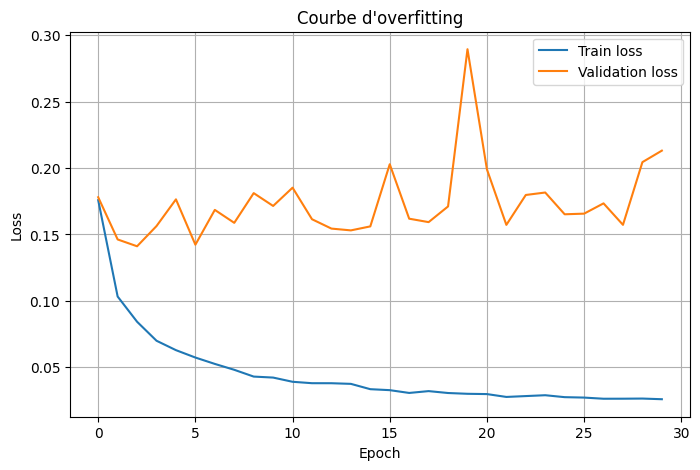

In [41]:
#Entrainement LSTM-AttentionLayer-P

model_lstm_att_db=SiameseLSTMAtt(ntokens, ninp, nhid, nlayers).to(device)

# 2. Optimizer — comme en cours
optimizer = torch.optim.Adam(model_lstm_att_db.parameters(), lr=1e-3)

# 3. Lancer l'entraînement
train_losses = train_model(train_loader_cv,val_loader_cv, model_lstm_att_db, optimizer, 30,"lstm_att_db")


## Evaluation

In [48]:
models = [
    ("lstm_cv", model_lstm_cv),("lstm_att_cv", model_lstm_att_cv),("lstm_job", model_lstm_job), ("lstm_att_job", model_lstm_att_job),("lstm_db", model_lstm_db), ("lstm_att_db", model_lstm_att_db)
]

for model_name, model in models:
  path = f"best_{model_name}.pt"

  model.load_state_dict(torch.load(path, map_location=device))
  model.eval()

  print(f"Evaluation du meilleur modèle : {model_name}")
  evaluate(test_loader, model, device)
  print()


Evaluation du meilleur modèle : lstm_cv
Accuracy : 0.877517
F1 macro : 0.8775
ROC-AUC  : 0.9589
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       298
           1       0.87      0.88      0.88       298

    accuracy                           0.88       596
   macro avg       0.88      0.88      0.88       596
weighted avg       0.88      0.88      0.88       596


Evaluation du meilleur modèle : lstm_att_cv
Accuracy : 0.941275
F1 macro : 0.9412
ROC-AUC  : 0.9904
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       298
           1       0.91      0.97      0.94       298

    accuracy                           0.94       596
   macro avg       0.94      0.94      0.94       596
weighted avg       0.94      0.94      0.94       596


Evaluation du meilleur modèle : lstm_job
Accuracy : 0.877517
F1 macro : 0.8771
ROC-AUC  : 0.9665
              precision    recall  f1-score   suppo